# The Selective Maturation Race
### A self-organizing Spiking Neural Network that learns a strict **1:1 localist code** under blocked training

This notebook is a detailed walkthrough of *why* the network is built the way it
is, not just *what* it does. We cover:

1. **The problem** — 8 line primitives on a 3×3 grid, presented in non-interleaved
   blocks, and why a naive network either *collapses* (one neuron grabs everything)
   or *deadlocks* (mutual suppression / runaway assemblies).
2. **The blueprint** — a *Selective Maturation Race* with three purely-local forces.
3. **The thought process** — the design *tensions* that had to be resolved for the
   physics to actually converge (these are the non-obvious parts).
4. **The implementation**, shown straight from the source.
5. **Running it** to a deterministic 8/8 consolidation.
6. **Diagrams & result images** — architecture schematic, spike rasters, membrane
   traces, receptive fields, cross-response matrix, pool utilization.

> Everything is fully-vectorized NumPy. The companion files are
> `snn_layer.py` (the layer), `scale_run_8line.py` (the blocked-learning driver),
> and `visualize.py` (an interactive HTML network simulator).

## 0 · Setup

We import the layer and the driver. NumPy does all the math; matplotlib draws the
diagrams. If matplotlib is missing, run `pip install matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import inspect

from snn_layer import SelfOrganizingSNNLayer, SNNConfig
from scale_run_8line import build_line_patterns, run_block, train, verify

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.facecolor": "#0d1117", "figure.facecolor": "white",
})
np.set_printoptions(precision=2, suppress=True)
print("numpy", np.__version__)

numpy 2.5.0


## 1 · The problem

**Inputs.** A 3×3 pixel grid (9-dimensional binary vectors). The 8 *primitives*
("lines") are the 3 rows, the 3 columns, and the 2 diagonals.

**Curriculum.** *Blocked* (a.k.a. non-interleaved) learning: we show primitive 0
for a while, then primitive 1, ... never mixing them. This is the regime where
artificial networks suffer **catastrophic interference** — learning block *k*
overwrites what was learned in block *k−1*.

**Goal.** A **1:1 localist code**: after training, each primitive should be
detected by *exactly one* dedicated neuron, and each neuron should respond to
*exactly one* primitive. No grandmother-cell sharing, no collapse.

**Why it's hard.** Two opposite failure modes:
- **Symbol collapse / hyper-active assemblies** — without competition, *many*
  neurons (or all 64) tune to the same strong pattern; or one greedy neuron grabs
  every block.
- **Trench-warfare deadlock** — with *too much* mutual inhibition, neurons crush
  each other into silence and nothing ever crosses threshold.

The geometry adds a twist: any two distinct lines meet in **at most one pixel**,
but the **centre pixel is shared by four lines** (row 1, col 1, both diagonals) —
the hardest overlap to disambiguate.

Let's look at the 8 primitives.

input_dim = 9 | primitives: ['ROW_0', 'ROW_1', 'ROW_2', 'COL_0', 'COL_1', 'COL_2', 'DIAG_\\', 'DIAG_/']

max overlap between two *distinct* lines: 1 pixel


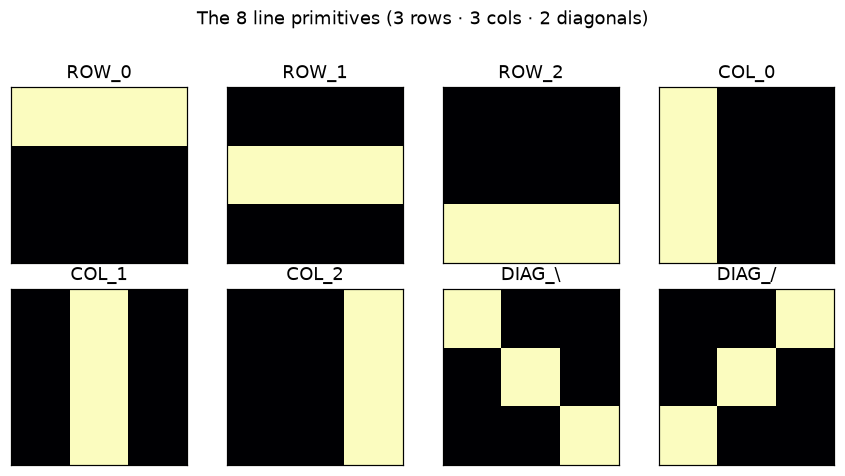

In [2]:
patterns, names = build_line_patterns()        # 8 x 9, grid=3 + diagonals
print("input_dim =", patterns.shape[1], "| primitives:", names)

# pixel-overlap matrix: how many pixels each pair of lines shares
overlap = (patterns @ patterns.T).astype(int)
print("\nmax overlap between two *distinct* lines:",
      (overlap - np.diag(np.diag(overlap))).max(), "pixel")

fig, axes = plt.subplots(2, 4, figsize=(8, 4.2))
for k, ax in enumerate(axes.flat):
    ax.imshow(patterns[k].reshape(3, 3), cmap="magma", vmin=0, vmax=1)
    ax.set_title(names[k], color="black"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The 8 line primitives (3 rows · 3 cols · 2 diagonals)", y=1.02)
plt.tight_layout(); plt.show()

## 2 · The blueprint: a *Selective Maturation Race*

The core lifecycle of every L2 neuron is **plastic → mature → retired**.

- A binary `mature_mask[i]` starts at 0. A neuron **matures** the moment its
  per-block moving-average firing rate ν_i crosses a **stability bar of 0.2**.
- **Strict Retirement Isolation:** the instant it matures, the neuron is
  *mathematically excised* from the competition. It (a) freezes its feedforward
  weights, (b) sets its learning rate to 0, (c) becomes a stable **non-leaky
  threshold detector**, and crucially (d) **drops its lateral inhibitory output to
  0**. That last point creates a **"power vacuum"** so the remaining plastic pool
  can freely claim the *next* block.

The "race" is: within a block, whichever plastic neuron pulls ahead first matures,
retires, and the curriculum advances. One winner per block ⇒ one neuron per symbol.

### The tri-partite local physics

Three interacting local forces govern self-organization — **no top-down daemon
touches the weights**.

| Force | Mechanism | What it cures |
|---|---|---|
| **A. Gated Homeostatic Bootstrap** (abundance) | silent neurons self-amplify | random-init blind spots: every neuron eventually fires on *something* |
| **B. Full Global Lateral Inhibition** (squeeze) | dense `w_lateral = −5` | hyper-active assemblies: one spike blankets the whole pool |
| **C. Selective Auto-Excitation Diagonal** (surge) | `W_ii = +2` (plastic only) | passive deadlock: the leader's own spike makes it run away & win |

Plus **Mass-Action synaptic bounding**: each neuron's feedforward weights are
L1-normalized to a fixed budget `W_total = 6`. As the winner reinforces, the
renormalization *strips* the shared mass off the runners-up — collapsing the
assembly to **N = 1**.

In [3]:
cfg = SNNConfig(input_dim=9)
for f in ("n_neurons","w_total","theta_rest","maturation_bar","nu_min",
          "nu_target","alpha","w_lateral","w_self","eta","v_leak"):
    print(f"{f:>15} = {getattr(cfg, f)}")

      n_neurons = 64
        w_total = 6.0
     theta_rest = 3.0
 maturation_bar = 0.2
         nu_min = 0.01
      nu_target = 0.01
          alpha = 0.1
      w_lateral = -5.0
         w_self = 2.0
            eta = 2.0
         v_leak = 0.9


### Architecture diagram

A conceptual schematic of one L2 neuron's situation: feedforward drive from the
input, the global inhibitory broadcast (the dense `w_lateral` term is exactly a
single **global inhibitory interneuron**), the `+2` self-excitation loop, and the
maturation gate that retires the winner and silences its inhibitory output.

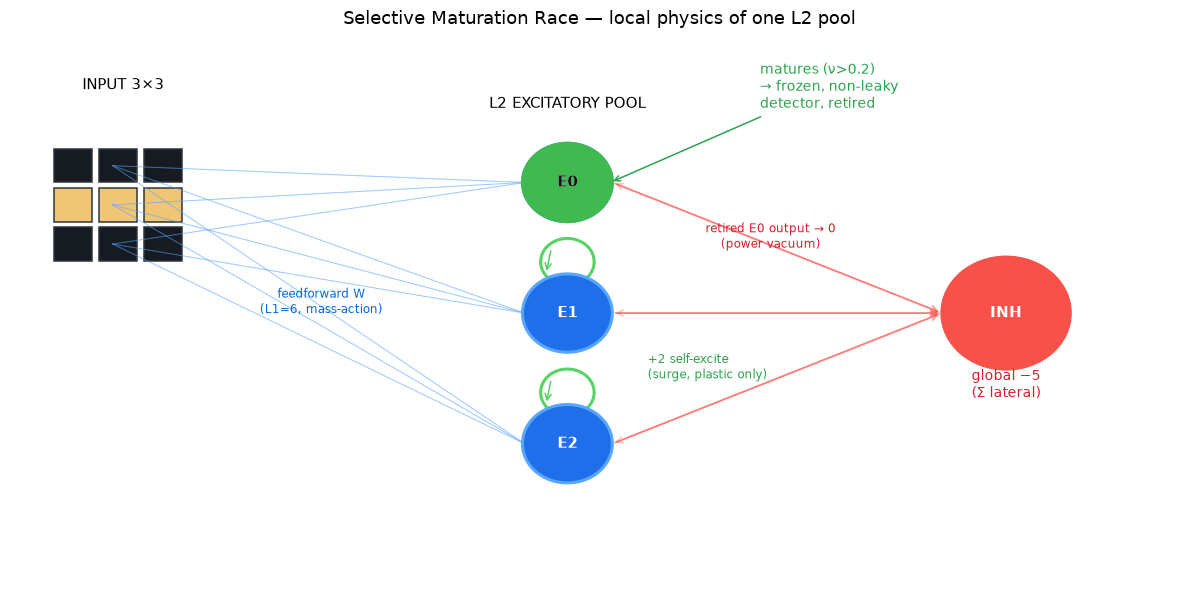

In [4]:
def draw_architecture():
    fig, ax = plt.subplots(figsize=(11, 5.6)); ax.set_facecolor("white")
    ax.set_xlim(0, 11); ax.set_ylim(0, 6); ax.axis("off")

    def node(x, y, r, fc, ec, label, tc="white", fs=10):
        ax.add_patch(patches.Circle((x, y), r, fc=fc, ec=ec, lw=2, zorder=3))
        ax.text(x, y, label, ha="center", va="center", color=tc,
                fontsize=fs, fontweight="bold", zorder=4)

    # input pixels (3x3)
    for r in range(3):
        for c in range(3):
            on = (r == 1)  # pretend "ROW_1" is presented
            ax.add_patch(patches.Rectangle((0.4+c*0.42, 4.4-r*0.42), 0.36, 0.36,
                         fc="#f0c674" if on else "#161b22", ec="#30363d"))
    ax.text(1.05, 5.4, "INPUT 3×3", ha="center", fontsize=10, color="black")

    # three excitatory neurons
    exc_y = [4.4, 3.0, 1.6]
    for i, y in enumerate(exc_y):
        node(5.2, y, 0.42, "#1f6feb", "#58a6ff", f"E{i}")
        for r in range(3):
            for c in range(3):
                ax.plot([0.95, 4.8], [4.58-r*0.42, y], color="#58a6ff",
                        lw=0.6, alpha=0.25, zorder=1)
    ax.text(5.2, 5.2, "L2 EXCITATORY POOL", ha="center", fontsize=10, color="black")

    # winner E0 -> matured/retired
    node(5.2, 4.4, 0.42, "#3fb950", "#3fb950", "E0", tc="#0d1117")
    ax.annotate("matures (ν>0.2)\n→ frozen, non-leaky\ndetector, retired",
                xy=(5.6, 4.4), xytext=(7.0, 5.2), color="#2da44e", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="#2da44e"))

    # global inhibitory interneuron
    node(9.3, 3.0, 0.6, "#f85149", "#f85149", "INH")
    ax.text(9.3, 2.1, "global −5\n(Σ lateral)", ha="center", fontsize=9, color="#cf222e")
    for y in exc_y:
        ax.annotate("", xy=(8.7, 3.0), xytext=(5.62, y),
                    arrowprops=dict(arrowstyle="->", color="#f85149", alpha=0.6, lw=1.2))
        ax.annotate("", xy=(5.62, y), xytext=(8.7, 3.0),
                    arrowprops=dict(arrowstyle="->", color="#f85149", alpha=0.35, lw=1))
    ax.text(7.1, 3.7, "retired E0 output → 0\n(power vacuum)", fontsize=8,
            color="#cf222e", ha="center")

    # self-excitation loops on plastic neurons
    for y in exc_y[1:]:
        ax.add_patch(patches.Arc((5.2, y+0.55), 0.5, 0.5, theta1=300, theta2=240,
                     color="#56d364", lw=2))
        ax.annotate("", xy=(5.0, y+0.42), xytext=(5.05, y+0.7),
                    arrowprops=dict(arrowstyle="->", color="#56d364"))
    ax.text(5.95, 2.3, "+2 self-excite\n(surge, plastic only)", fontsize=8, color="#2da44e")

    ax.text(2.9, 3.0, "feedforward W\n(L1=6, mass-action)", fontsize=8,
            color="#0969da", ha="center")
    ax.set_title("Selective Maturation Race — local physics of one L2 pool",
                 fontsize=12, color="black")
    plt.tight_layout(); plt.show()

draw_architecture()

## 3 · The thought process — design tensions that had to be resolved

The blueprint *sounds* clean, but several forces **fight each other**. Getting
convergence meant resolving these tensions. This section is the real "why".

### Tension 1 — Bootstrap × Mass-Action cancel out
The homeostatic bootstrap *multiplies* a silent neuron's weight vector to turn up
its gain. But mass-action *renormalizes* the L1 norm back to `W_total`. A pure
"multiply then renormalize every step" does **nothing** — the scale-up is undone.

**Resolution:** mass-action renormalization is applied **only when a neuron fires
and learns**. A *silent* neuron never fires, so its bootstrapped mass is allowed
to inflate (L1 grows past 6) until its drive finally crosses threshold. The
instant it sparks, the Hebbian step renormalizes it back to 6 — the scaffold
"melts away". This is why the boost is gated on `nu < nu_min`.

### Tension 2 — The power vacuum could let a *second* neuron claim the same block
A matured neuron drops its inhibitory output to 0 (good for the *next* block). But
if we kept presenting the *same* pattern, the now-uninhibited pool could mature a
**second** neuron on it.

**Resolution lives in the curriculum, not the physics:** the block *ends* the
moment a neuron matures (the race is won), and a claimed primitive is **dropped
from the rotation**. The only thing the driver reads back from the net is the
emergent maturation event — it never steers weights.

### Tension 3 — A multiplicative boost can't *redirect* a neuron to a disjoint line
Two different lines can be pixel-disjoint. A neuron already tuned to line A has
~0 weight on line B's pixels; multiplying by a scalar can't grow zeros, so it can
never claim B.

**Resolution:** make the winner-take-all **fast and explosive** (the `+2` surge +
the `−5` squeeze) so that runners-up are quenched *before* they learn much and stay
near-uniform "generalists", ready to claim later blocks. With N=64 ≫ 8 there are
always fresh generalists available.

### Tension 4 — Threshold geometry
Set `θ = 0.5 · W_total = 3`. A fully-consolidated line detector (weight 2 on each
of its k=3 pixels) drives to `W_total = 6 ≥ θ` on its own line, but only `2 < θ`
on a line that shares a single pixel. Since no two distinct lines share more than
one pixel, **every off-target drive stays below threshold** — clean separation.

## 4 · The implementation

The whole layer is a few vectorized operations. Let's read the load-bearing
methods straight from the source.

### The single simulation step

In [5]:
print(inspect.getsource(SelfOrganizingSNNLayer.step))

    def step(self, x: np.ndarray) -> np.ndarray:
        cfg = self.cfg
        plastic = (self.mature_mask == 0)

        # A. abundance: silent plastic neurons self-amplify before integrating.
        self._homeostatic_boost()

        # Feedforward drive  (W^T @ x), broadcast across the pool.
        i_ff = self.W.T @ x                                    # (N,)
        # B + C. lateral squeeze + selective surge from last step's spikes.
        i_lat = self._lateral_current(self.spikes)             # (N,)

        # Membrane integration. Matured neurons are non-leaky, isolated
        # threshold detectors (no leak, no lateral); plastic neurons leak.
        leak = np.where(plastic, cfg.v_leak, 1.0)
        self.v = leak * self.v + i_ff + i_lat
        np.maximum(self.v, cfg.v_floor, out=self.v)            # no negative wells

        # Spike + hard reset.
        spikes = (self.v >= cfg.theta_rest).astype(np.float64)
        self.v = np.where(spikes > 0, 0.0, self.v)

        # Per-

**B + C — lateral squeeze and selective surge.** Note how a matured neuron is
excised *both* ways: only un-matured spikes exert lateral force (`eff = spikes *
plastic`, the power vacuum), and matured neurons receive no lateral current
(`i_lat * plastic`).

In [6]:
print(inspect.getsource(SelfOrganizingSNNLayer._lateral_current))

    def _lateral_current(self, spikes: np.ndarray) -> np.ndarray:
        """I_lat[j] = sum_i L[j, i] * spikes_i, with matured neurons excised.

        L is 100% dense: off-diagonal = w_lateral (Squeeze), diagonal =
        +w_self for un-matured neurons only (Surge). A matured neuron's
        *output* is gated to 0 (the "power vacuum"); a matured neuron also
        receives no lateral current (a stable, isolated threshold detector).
        """
        cfg = self.cfg
        plastic = (self.mature_mask == 0).astype(np.float64)   # (N,)

        # Only un-matured presynaptic spikes exert any lateral force.
        eff = spikes * plastic                                  # (N,)

        # Global squeeze: every plastic spike blankets the whole pool.
        i_lat = cfg.w_lateral * (eff.sum() - eff)               # off-diagonal @ eff
        # Selective surge: a plastic neuron re-injects +w_self into itself.
        i_lat = i_lat + cfg.w_self * eff                        # diagonal @ ef

**A — the gated homeostatic bootstrap** (the exact inverse-firing-rate scaling),
and the **mass-action Hebbian collapse** (additive Hebbian onto co-active inputs,
then per-column L1 renormalization to `W_total`).

In [7]:
print(inspect.getsource(SelfOrganizingSNNLayer._homeostatic_boost))
print(inspect.getsource(SelfOrganizingSNNLayer._hebbian_update))

    def _homeostatic_boost(self) -> None:
        """Silent un-matured neurons multiplicatively turn up their own gain.

        Scaling = 1 + alpha * (nu_target / max(0.001, nu)) * max(0, nu_min - nu)

        The scaffold melts the instant the neuron sparks (nu > nu_min): the
        ``max(0, nu_min - nu)`` gate -> 0 AND the next post-spike Hebbian step
        re-normalizes the inflated L1 mass back to W_total.
        """
        cfg = self.cfg
        nu = self.nu
        silent = (nu < cfg.nu_min) & (self.mature_mask == 0)

        scaling = 1.0 + (
            cfg.alpha
            * (cfg.nu_target / np.maximum(0.001, nu))
            * np.maximum(0.0, cfg.nu_min - nu)
        )
        scaling = np.where(silent, scaling, 1.0)               # (N,)
        # Broadcast the per-neuron gain across the input dimension.
        self.W *= scaling[None, :]

    def _hebbian_update(self, x: np.ndarray, spikes: np.ndarray) -> None:
        """Un-matured spikers pull weight onto the active

**The race verdict** — mature exactly one neuron (the strongest), freeze and
retire it.

In [8]:
print(inspect.getsource(SelfOrganizingSNNLayer.try_mature))

    def try_mature(self, pattern_id: int) -> int | None:
        """If any *plastic* neuron has crossed the stability bar this block,
        mature exactly one (the strongest), freeze it, and retire it.

        Returns the matured neuron index, else None.
        """
        cfg = self.cfg
        cand = (self.nu >= cfg.maturation_bar) & (self.mature_mask == 0)
        if not cand.any():
            return None

        # Deterministic single winner: strongest nu (ties -> lowest index).
        nu_masked = np.where(cand, self.nu, -np.inf)
        i = int(np.argmax(nu_masked))

        # Strict Retirement Isolation: freeze W, lr->0, drop lateral output->0.
        # (All three are realized structurally by mature_mask gating in step().)
        self.mature_mask[i] = 1
        self.tuned_pattern[i] = pattern_id
        self.v[i] = 0.0
        return i



## 5 · Watch a single block's race

Let's instrument *one* block step-by-step and plot the dynamics: the spike raster,
the leader-vs-loser membrane potentials, and the firing-rate ν climbing to the
0.2 maturation bar.

block ROW_0: winner = neuron #0, matured in 6 steps


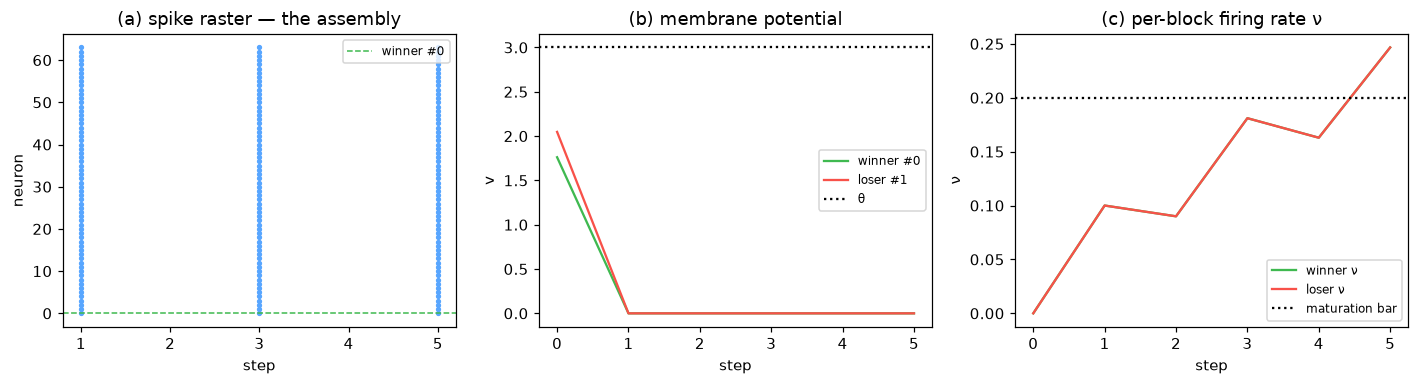

In [9]:
def record_block(layer, x, pid, max_steps=120):
    layer.reset_transient()
    T = []
    for t in range(max_steps):
        layer.step(x)
        T.append(dict(spikes=np.where(layer.spikes > 0)[0].copy(),
                      v=layer.v.copy(), nu=layer.nu.copy()))
        w = layer.try_mature(pid)
        if w is not None:
            return T, w
    return T, None

L = SelfOrganizingSNNLayer(SNNConfig(input_dim=9, seed=0))
trace, winner = record_block(L, patterns[0], 0)
print(f"block {names[0]}: winner = neuron #{winner}, matured in {len(trace)} steps")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for t, s in enumerate(trace):
    ax[0].scatter([t]*len(s["spikes"]), s["spikes"], s=6, c="#58a6ff")
ax[0].axhline(winner, color="#3fb950", lw=1, ls="--", label=f"winner #{winner}")
ax[0].set(title="(a) spike raster — the assembly", xlabel="step", ylabel="neuron")
ax[0].legend(fontsize=8, facecolor="white")
losers = [i for i in range(64) if i != winner]
loser = max(losers, key=lambda i: trace[-1]["nu"][i])
ax[1].plot([s["v"][winner] for s in trace], color="#3fb950", label=f"winner #{winner}")
ax[1].plot([s["v"][loser] for s in trace], color="#f85149", label=f"loser #{loser}")
ax[1].axhline(L.cfg.theta_rest, color="black", ls=":", label="θ")
ax[1].set(title="(b) membrane potential", xlabel="step", ylabel="v"); ax[1].legend(fontsize=8, facecolor="white")
ax[2].plot([s["nu"][winner] for s in trace], color="#3fb950", label="winner ν")
ax[2].plot([s["nu"][loser] for s in trace], color="#f85149", label="loser ν")
ax[2].axhline(0.2, color="black", ls=":", label="maturation bar")
ax[2].set(title="(c) per-block firing rate ν", xlabel="step", ylabel="ν"); ax[2].legend(fontsize=8, facecolor="white")
for a in ax: a.set_facecolor("white")
plt.tight_layout(); plt.show()

### Ablation: is the lateral squeeze actually load-bearing?

Compare the size of the firing assembly *within a block* with full physics vs with
the squeeze and surge switched off. Without them the assembly runs away to **all
64 neurons** (a hyper-active assembly — exactly the deadlock we set out to avoid);
with them it stays bounded and resolves to a single winner.

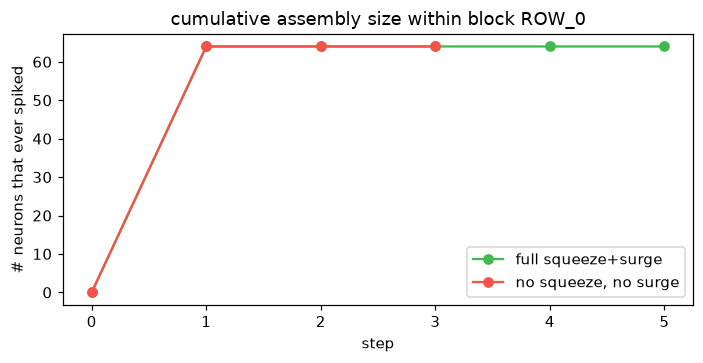

full physics -> bounded assembly;  ablated -> runs away to 64 neurons


In [10]:
def assembly_curve(w_lateral, w_self, seed=3, steps=20):
    Lab = SelfOrganizingSNNLayer(SNNConfig(input_dim=9, seed=seed,
                                           w_lateral=w_lateral, w_self=w_self))
    Lab.reset_transient(); ever, curve = set(), []
    for _ in range(steps):
        Lab.step(patterns[0]); ever |= set(np.where(Lab.spikes > 0)[0].tolist())
        curve.append(len(ever))
        if Lab.try_mature(0) is not None: break
    return curve

full = assembly_curve(-5.0, 2.0)
none = assembly_curve(0.0, 0.0)
plt.figure(figsize=(6.5, 3.4))
plt.plot(full, "-o", color="#3fb950", label="full squeeze+surge")
plt.plot(none, "-o", color="#f85149", label="no squeeze, no surge")
plt.gca().set_facecolor("white")
plt.title("cumulative assembly size within block ROW_0")
plt.xlabel("step"); plt.ylabel("# neurons that ever spiked"); plt.legend(facecolor="white")
plt.tight_layout(); plt.show()
print("full physics -> bounded assembly;  ablated -> runs away to", max(none), "neurons")

## 6 · Run the full blocked curriculum to 8/8

Present the 8 lines in strict chronological blocks. Each won block matures and
retires one neuron; claimed primitives drop out. We loop until all 8 are owned by
unique, retired neurons.

In [11]:
layer, patterns, names, claimed = train(seed=0, verbose=True)
ok = verify(layer, patterns, names, claimed)

  [epoch 00] block  ROW_0 -> neuron #0  matured & retired (mature pool = 1)
  [epoch 00] block  ROW_1 -> neuron #2  matured & retired (mature pool = 2)
  [epoch 00] block  ROW_2 -> neuron #61 matured & retired (mature pool = 3)
  [epoch 00] block  COL_0 -> neuron #1  matured & retired (mature pool = 4)
  [epoch 00] block  COL_1 -> neuron #3  matured & retired (mature pool = 5)
  [epoch 00] block  COL_2 -> neuron #13 matured & retired (mature pool = 6)
  [epoch 00] block DIAG_\ -> neuron #4  matured & retired (mature pool = 7)
  [epoch 00] block DIAG_/ -> neuron #5  matured & retired (mature pool = 8)

Consolidation reached after epoch 0.

FINAL SINGLE-HUB CONSOLIDATION MAP
   ROW_0  ->  neuron #  0   drive= 5.46/3.0   single-firing=[0]   [OK]
   ROW_1  ->  neuron #  2   drive= 5.22/3.0   single-firing=[2]   [OK]
   ROW_2  ->  neuron # 61   drive= 5.16/3.0   single-firing=[61]   [OK]
   COL_0  ->  neuron #  1   drive= 5.40/3.0   single-firing=[1]   [OK]
   COL_1  ->  neuron #  3   drive

## 7 · Result images

### Cross-response matrix — selectivity

Rows = presented line, columns = the owning (retired) neuron. The diagonal is the
on-target drive; everything off-diagonal is leakage. A spike needs drive ≥ θ, so a
clean code has a **bright diagonal above θ and everything else below it**.

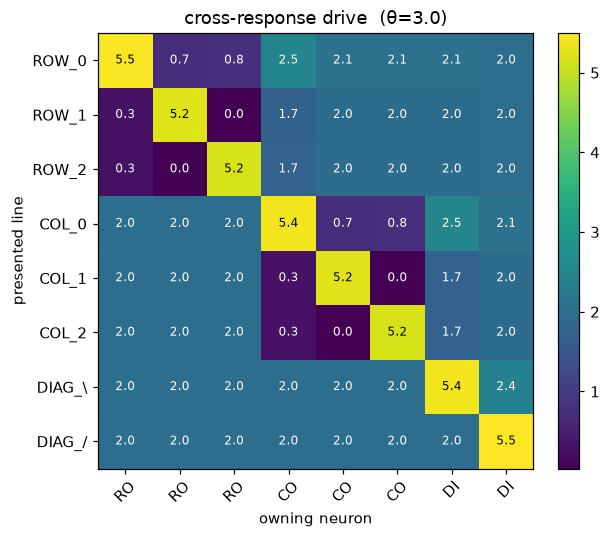

on-target min = 5.16   off-target max = 2.52   separation margin = +2.64


In [12]:
resp = np.stack([layer.response(p) for p in patterns])     # 8 x 64
owners = [claimed[p] for p in range(8)]
M = resp[:, owners]                                        # 8 x 8
theta = layer.cfg.theta_rest

fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.imshow(M, cmap="viridis")
for i in range(8):
    for j in range(8):
        v = M[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white" if v < theta else "black", fontsize=8)
ax.set_xticks(range(8)); ax.set_xticklabels([n[:2] for n in names], rotation=45)
ax.set_yticks(range(8)); ax.set_yticklabels(names)
ax.set_xlabel("owning neuron"); ax.set_ylabel("presented line")
ax.set_title(f"cross-response drive  (θ={theta})")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

diag = np.diag(M); off = M - np.diag(diag)
print(f"on-target min = {diag.min():.2f}   off-target max = {off.max():.2f}   "
      f"separation margin = +{diag.min()-off.max():.2f}")

### Receptive fields of the 8 retired neurons

Each owning neuron's learned feedforward weights, reshaped to the 3×3 grid — they
recover the line they detect.

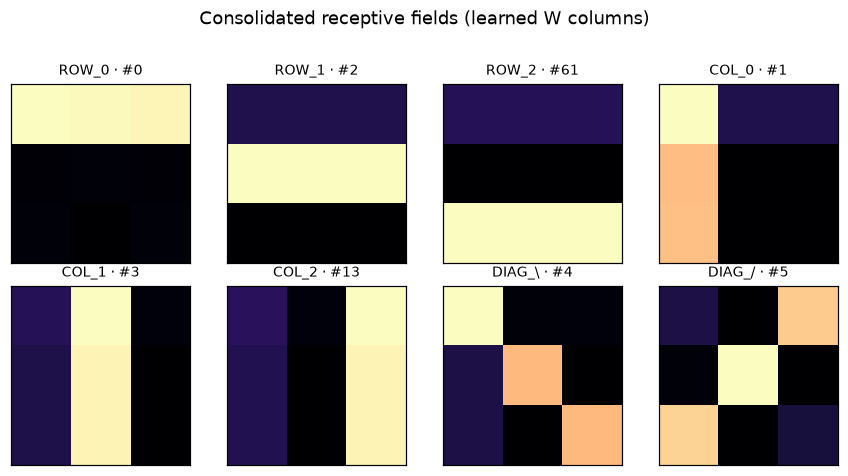

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4.2))
for p, ax in enumerate(axes.flat):
    rf = layer.W[:, owners[p]].reshape(3, 3)
    ax.imshow(rf, cmap="magma")
    ax.set_title(f"{names[p]} · #{owners[p]}", color="black", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Consolidated receptive fields (learned W columns)", y=1.02)
plt.tight_layout(); plt.show()

### Maturation latency — the race order

Most blocks resolve in a handful of steps; a couple fought on an already-tuned
substrate take longer. All well within the block budget.

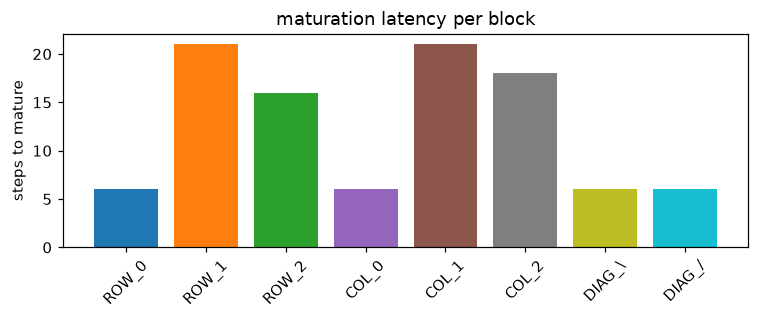

mean latency: 12.5 steps


In [14]:
Lt = SelfOrganizingSNNLayer(SNNConfig(input_dim=9, seed=0)); cl = {}; lats = {}
for ep in range(40):
    for p in range(8):
        if p in cl: continue
        Lt.reset_transient(); steps = None
        for t in range(Lt.cfg.max_block_steps):
            Lt.step(patterns[p])
            if Lt.try_mature(p) is not None: steps = t+1; break
        if steps is not None: cl[p] = 1; lats[p] = steps
    if len(cl) == 8: break

plt.figure(figsize=(7, 3))
cols = plt.cm.tab10(np.linspace(0, 1, 8))
plt.bar([names[p] for p in range(8)], [lats[p] for p in range(8)], color=cols)
plt.gca().set_facecolor("white"); plt.ylabel("steps to mature")
plt.title("maturation latency per block"); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()
print("mean latency:", np.mean(list(lats.values())).round(1), "steps")

## 8 · Pool utilization — the dense-vs-sparse substrate story

A subtle finding: the *readout* (the 8 retired neurons) is perfect in both modes,
but the **substrate** differs. The aggressive abundance bootstrap recruits nearly
the whole pool into redundant, half-formed "hot spare" line detectors. The
`sparse_substrate` flag melts a block's spent runners-up back into the reservoir,
so only the 8 retired neurons stay tuned.

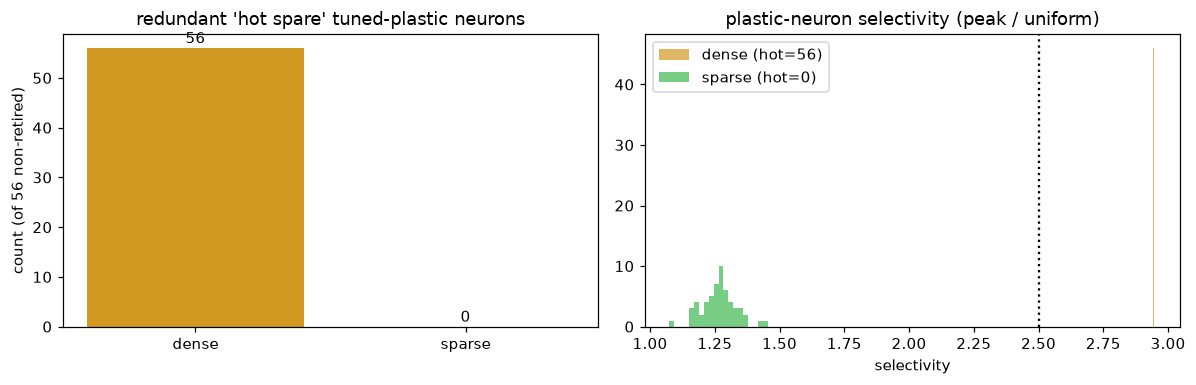

dense  : 56 hot spares, peak L1 mass 6.0
sparse : 0 hot spares, peak L1 mass 6.4


In [15]:
def pool_profile(sparse):
    Lp = SelfOrganizingSNNLayer(SNNConfig(input_dim=9, seed=0, sparse_substrate=sparse))
    cl = {}
    for ep in range(40):
        for p in range(8):
            if p in cl: continue
            w = run_block(Lp, patterns[p], p)
            if w is not None: cl[p] = w
        if len(cl) == 8: break
    plastic = np.where(Lp.mature_mask == 0)[0]
    sel = np.array([Lp.W[:, i].max() / (Lp.W[:, i].sum()/9) for i in plastic])
    return Lp, sel, int((sel > 2.5).sum())

Ld, seld, hot_d = pool_profile(False)
Ls, sels, hot_s = pool_profile(True)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["dense", "sparse"], [hot_d, hot_s], color=["#d29922", "#3fb950"])
ax[0].set_title("redundant 'hot spare' tuned-plastic neurons")
ax[0].set_ylabel("count (of 56 non-retired)")
for i, v in enumerate([hot_d, hot_s]): ax[0].text(i, v+1, str(v), ha="center")
ax[1].hist(seld, bins=20, alpha=0.7, color="#d29922", label=f"dense (hot={hot_d})")
ax[1].hist(sels, bins=20, alpha=0.7, color="#3fb950", label=f"sparse (hot={hot_s})")
ax[1].axvline(2.5, color="black", ls=":"); ax[1].legend(facecolor="white")
ax[1].set_title("plastic-neuron selectivity (peak / uniform)")
ax[1].set_xlabel("selectivity")
for a in ax: a.set_facecolor("white")
plt.tight_layout(); plt.show()
print(f"dense  : {hot_d} hot spares, peak L1 mass {Ld.W.sum(0).max():.1f}")
print(f"sparse : {hot_s} hot spares, peak L1 mass {Ls.W.sum(0).max():.1f}")

### Full-pool snapshot diagram (the "actual network", static)

The 64 L2 neurons laid out in a grid and coloured by final state — retired (by
symbol), hot-spare, or reservoir — with the strong learned feedforward
connections drawn from the 9 input pixels. This is the matplotlib analogue of the
interactive `snn_visualization.html`.

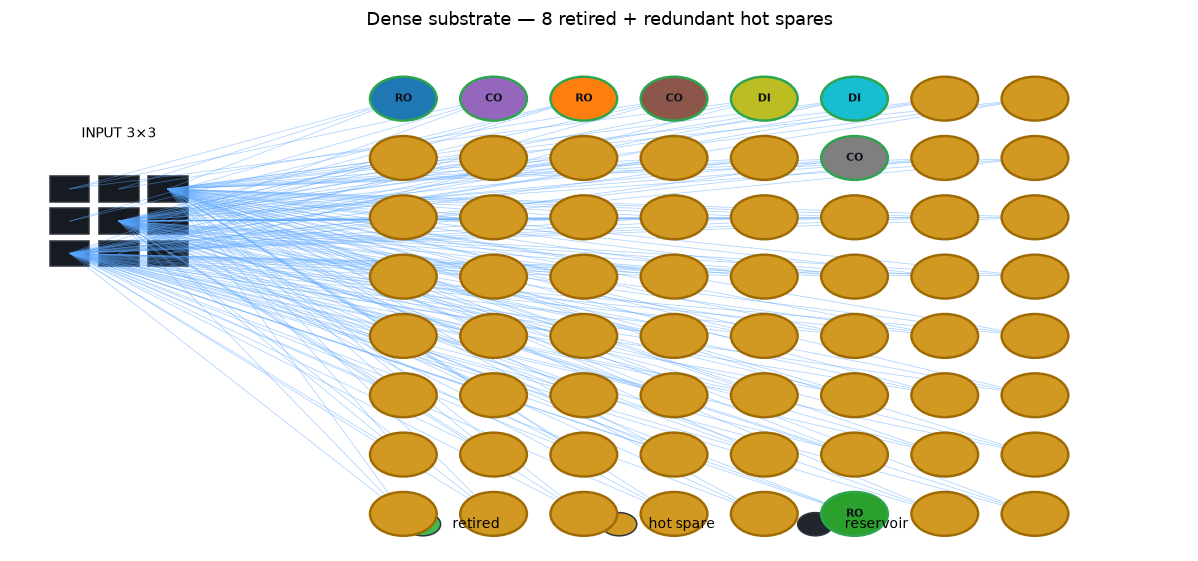

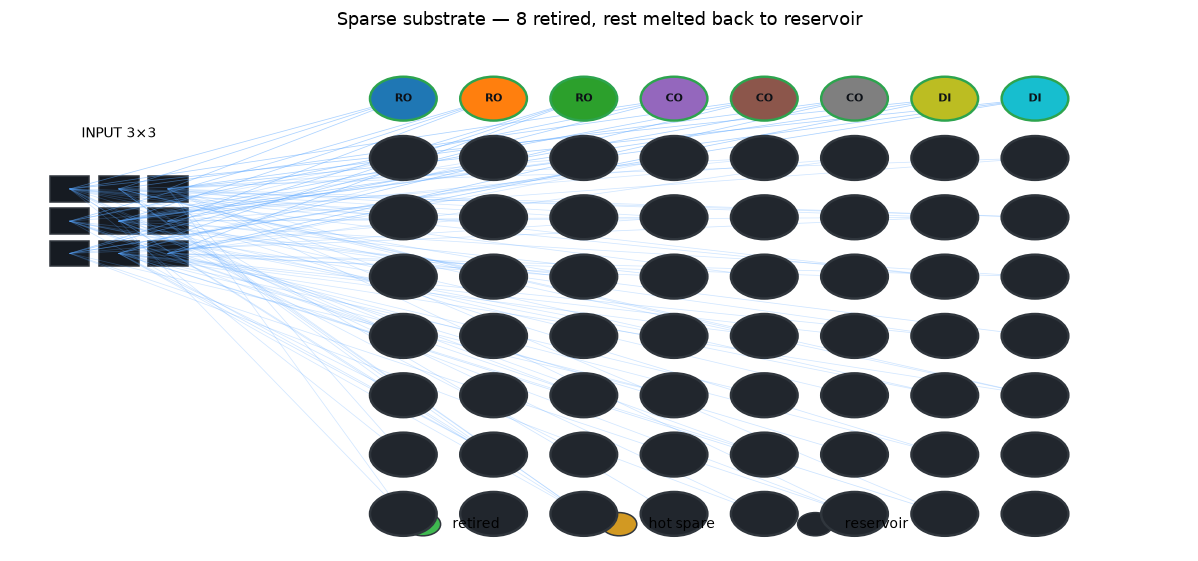

In [16]:
def draw_pool(Lp, title):
    fig, ax = plt.subplots(figsize=(11, 5.2)); ax.set_facecolor("white"); ax.axis("off")
    ax.set_xlim(0, 12); ax.set_ylim(0, 8)
    tab = plt.cm.tab10(np.linspace(0, 1, 8))
    inpos = []
    for r in range(3):
        for c in range(3):
            x, y = 0.6 + c*0.5, 5.6 - r*0.5; inpos.append((x, y))
            ax.add_patch(patches.Rectangle((x-0.2, y-0.2), 0.4, 0.4,
                         fc="#161b22", ec="#30363d"))
    ax.text(1.1, 6.4, "INPUT 3×3", ha="center", color="black", fontsize=9)
    npos = []
    for i in range(64):
        x, y = 4 + (i % 8)*0.92, 7 - (i // 8)*0.92; npos.append((x, y))
    maxw = Lp.W.max()
    for i in range(64):
        for d in range(9):
            w = Lp.W[d, i]
            if w > 0.8:
                ax.plot([inpos[d][0], npos[i][0]], [inpos[d][1], npos[i][1]],
                        color="#58a6ff", lw=0.5, alpha=min(0.5, w/maxw*0.6), zorder=1)
    for i in range(64):
        sel = Lp.W[:, i].max()/(Lp.W[:, i].sum()/9)
        if Lp.mature_mask[i]:
            fc = tab[Lp.tuned_pattern[i]]; ec = "#2da44e"
        elif sel > 2.5:
            fc = "#d29922"; ec = "#9e6a03"
        else:
            fc = "#21262d"; ec = "#30363d"
        ax.add_patch(patches.Circle(npos[i], 0.34, fc=fc, ec=ec, lw=1.6, zorder=3))
        if Lp.mature_mask[i]:
            ax.text(*npos[i], names[Lp.tuned_pattern[i]][:2], ha="center",
                    va="center", fontsize=7, fontweight="bold", color="#0d1117", zorder=4)
    ax.set_title(title, color="black", fontsize=12)
    for k, (lab, col) in enumerate([("retired", "#3fb950"),
                                    ("hot spare", "#d29922"),
                                    ("reservoir", "#21262d")]):
        ax.add_patch(patches.Circle((4.2+k*2.0, 0.4), 0.18, fc=col, ec="#30363d"))
        ax.text(4.5+k*2.0, 0.4, lab, va="center", fontsize=9, color="black")
    plt.tight_layout(); plt.show()

draw_pool(Ld, "Dense substrate — 8 retired + redundant hot spares")
draw_pool(Ls, "Sparse substrate — 8 retired, rest melted back to reservoir")

## 9 · Robustness — it's not a lucky seed

Re-run the whole pipeline across 20 seeds and confirm a perfect, unique 8/8 every
time with zero foreign-firing.

In [17]:
def one_run(seed, sparse=True):
    Lr = SelfOrganizingSNNLayer(SNNConfig(input_dim=9, seed=seed, sparse_substrate=sparse))
    cl = {}
    for ep in range(40):
        for p in range(8):
            if p in cl: continue
            w = run_block(Lr, patterns[p], p)
            if w is not None: cl[p] = w
        if len(cl) == 8: break
    resp = np.stack([Lr.response(p) for p in patterns])
    foreign = sum(1 for p in range(8) for i in range(64)
                  if Lr.mature_mask[i] and Lr.tuned_pattern[i] != p
                  and resp[p, i] >= Lr.cfg.theta_rest)
    return len(cl), len(set(cl.values())), foreign

res = [one_run(s) for s in range(20)]
passes = sum(1 for c, u, f in res if c == 8 and u == 8 and f == 0)
print(f"perfect, unique 8/8 with 0 foreign-firing: {passes}/20 seeds")

perfect, unique 8/8 with 0 foreign-firing: 20/20 seeds


## 10 · Summary

- A **Selective Maturation Race** turns blocked learning — normally a recipe for
  catastrophic interference — into a clean **1:1 localist code**.
- Three local forces (**abundance / squeeze / surge**) + **mass-action bounding**
  + **strict retirement isolation** are individually simple but had to be balanced
  against each other; the non-obvious work was resolving the four design tensions
  in §3.
- The result is deterministic and robust: **perfect 8/8** across seeds, with a
  selectivity margin comfortably above threshold.
- `sparse_substrate=True` additionally keeps the pool itself clean (no redundant
  hot spares), at no cost to the readout.

For the live, animated version of these dynamics — membrane potentials, spikes,
weights, the global inhibitory cell pulsing on every spike — open
`snn_visualization.html` (generated by `visualize.py`).